# 0. Importing Libraries

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPClassifier


import warnings
warnings.filterwarnings('ignore')

# 1. Data Loading and Initial Inspection

In [77]:

# Load the data
# df = pd.read_csv('/Users/mahendranathgulla/Downloads/somoker/train.csv')
# test_df = pd.read_csv('/Users/mahendranathgulla/Downloads/somoker/test.csv')

df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')


print("Train dataset shape:", df.shape)
print("Test dataset shape:", test_df.shape)
print("\nTrain columns:", df.columns.tolist())
print("\nTest columns:", test_df.columns.tolist())

Train dataset shape: (38984, 23)
Test dataset shape: (16708, 22)

Train columns: ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries', 'smoking']

Test columns: ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries']


In [78]:
df.head() #training_dataset

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,97,239,153,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,88,211,128,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,80,193,120,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,249,210,366,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,100,179,200,47,92,14.9,1,1.2,26,28,15,0,0


In [79]:
test_df.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
0,40,170,65,75.1,1.0,0.9,1,1,120,70,102,225,260,41,132,15.7,1,0.8,24,26,32,0
1,45,170,75,89.0,0.7,1.2,1,1,100,67,96,258,345,49,140,15.7,1,1.1,26,28,138,0
2,30,180,90,94.0,1.0,0.8,1,1,115,72,88,177,103,53,103,13.5,1,1.0,19,29,30,0
3,60,170,50,73.0,0.5,0.7,1,1,118,78,86,187,70,65,108,14.1,1,1.3,31,28,33,0
4,30,170,65,78.0,1.5,1.0,1,1,110,70,87,190,210,45,103,14.7,1,0.8,21,21,19,0


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38984 entries, 0 to 38983
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  38984 non-null  int64  
 1   height(cm)           38984 non-null  int64  
 2   weight(kg)           38984 non-null  int64  
 3   waist(cm)            38984 non-null  float64
 4   eyesight(left)       38984 non-null  float64
 5   eyesight(right)      38984 non-null  float64
 6   hearing(left)        38984 non-null  int64  
 7   hearing(right)       38984 non-null  int64  
 8   systolic             38984 non-null  int64  
 9   relaxation           38984 non-null  int64  
 10  fasting blood sugar  38984 non-null  int64  
 11  Cholesterol          38984 non-null  int64  
 12  triglyceride         38984 non-null  int64  
 13  HDL                  38984 non-null  int64  
 14  LDL                  38984 non-null  int64  
 15  hemoglobin           38984 non-null 

In [81]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,38984.0,44.127591,12.063564,20.0,40.0,40.0,55.0,85.0
height(cm),38984.0,164.689488,9.187507,130.0,160.0,165.0,170.0,190.0
weight(kg),38984.0,65.938718,12.896581,30.0,55.0,65.0,75.0,135.0
waist(cm),38984.0,82.062115,9.326798,51.0,76.0,82.0,88.0,129.0
eyesight(left),38984.0,1.014955,0.498527,0.1,0.8,1.0,1.2,9.9
eyesight(right),38984.0,1.008768,0.493813,0.1,0.8,1.0,1.2,9.9
hearing(left),38984.0,1.025369,0.157246,1.0,1.0,1.0,1.0,2.0
hearing(right),38984.0,1.026190,0.159703,1.0,1.0,1.0,1.0,2.0
systolic,38984.0,121.475631,13.643521,71.0,112.0,120.0,130.0,233.0
relaxation,38984.0,75.994408,9.658734,40.0,70.0,76.0,82.0,146.0


# 2. Data Cleaning

In [82]:
# Check for missing values (returns a boolean DataFrame)
print(df.isnull().sum())

age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64


In [83]:
print("Number of Duplicated Rows:")
print("--------------------------")
display(df.duplicated().sum())
print("\n")

print("Number of Unique Values:")
print("------------------------")
display(df.nunique())

Number of Duplicated Rows:
--------------------------


np.int64(5517)



Number of Unique Values:
------------------------


,0
age,14
height(cm),13
weight(kg),22
waist(cm),545
eyesight(left),19
eyesight(right),17
hearing(left),2
hearing(right),2
systolic,125
relaxation,94


In [84]:
def remove_duplicates(df):
    """
    Remove duplicate rows from a DataFrame and print the number of duplicates found and removed.
    Parameters:
    - df: pandas DataFrame
    Returns:
    - df_no_duplicates: DataFrame with duplicates removed
    """

    # Identify duplicates
    duplicates = df[df.duplicated()]

    # Print number of duplicates found and removed
    print(f"Number of duplicates found and removed: {len(duplicates)}")

    # Remove duplicates
    df_no_duplicates = df.drop_duplicates()

    return df_no_duplicates

print(df.shape)
train_df = remove_duplicates(df)
print(train_df.shape)

(38984, 23)
Number of duplicates found and removed: 5517
(33467, 23)


In [85]:
cats = train_df[['dental caries','Urine protein','hearing(right)','hearing(left)']]
cats.head(10)

,dental caries,Urine protein,hearing(right),hearing(left)
0,1,1,1,1
1,1,1,1,1
2,0,3,1,1
3,0,1,1,1
4,0,1,1,1
5,0,1,2,2
6,0,1,1,1
7,1,2,1,1
8,0,2,1,1
9,0,1,1,1


# 3. Exploratory Data Analysis (EDA)

## Correlation Matrix

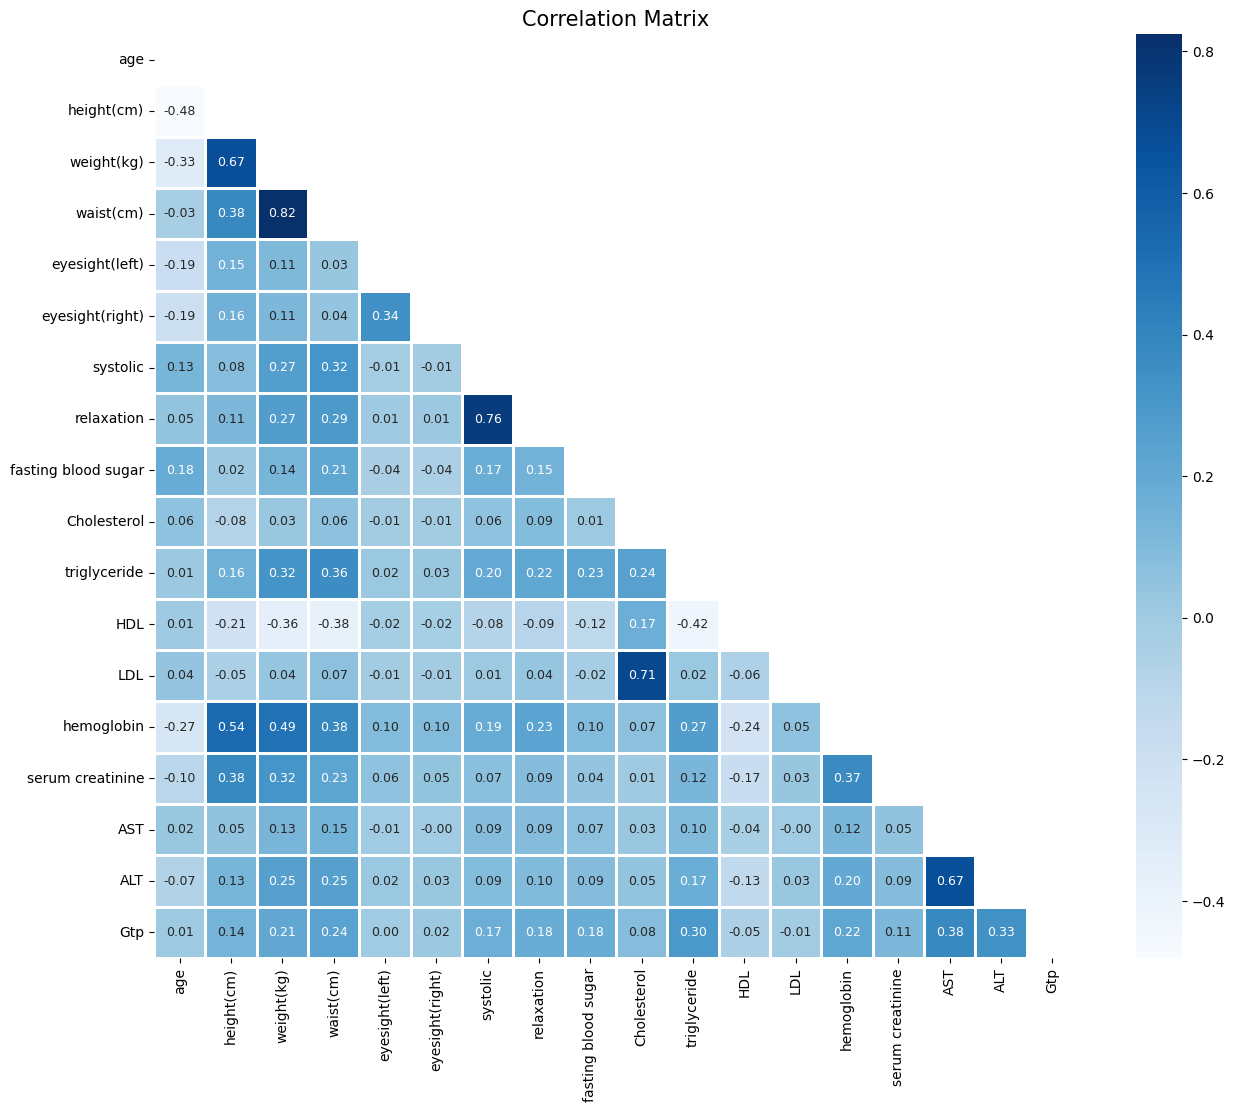

In [86]:
num_var = [column for column in df.columns if df[column].nunique() > 10]
cat_var = [column for column in df.columns if df[column].nunique() < 10]


corr_matrix = train_df[num_var].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='Blues', fmt='.2f', linewidths=1, square=True, annot_kws={"size": 9} )
plt.title('Correlation Matrix', fontsize=15)
plt.show()

## Scatterplot of highly correlated variables

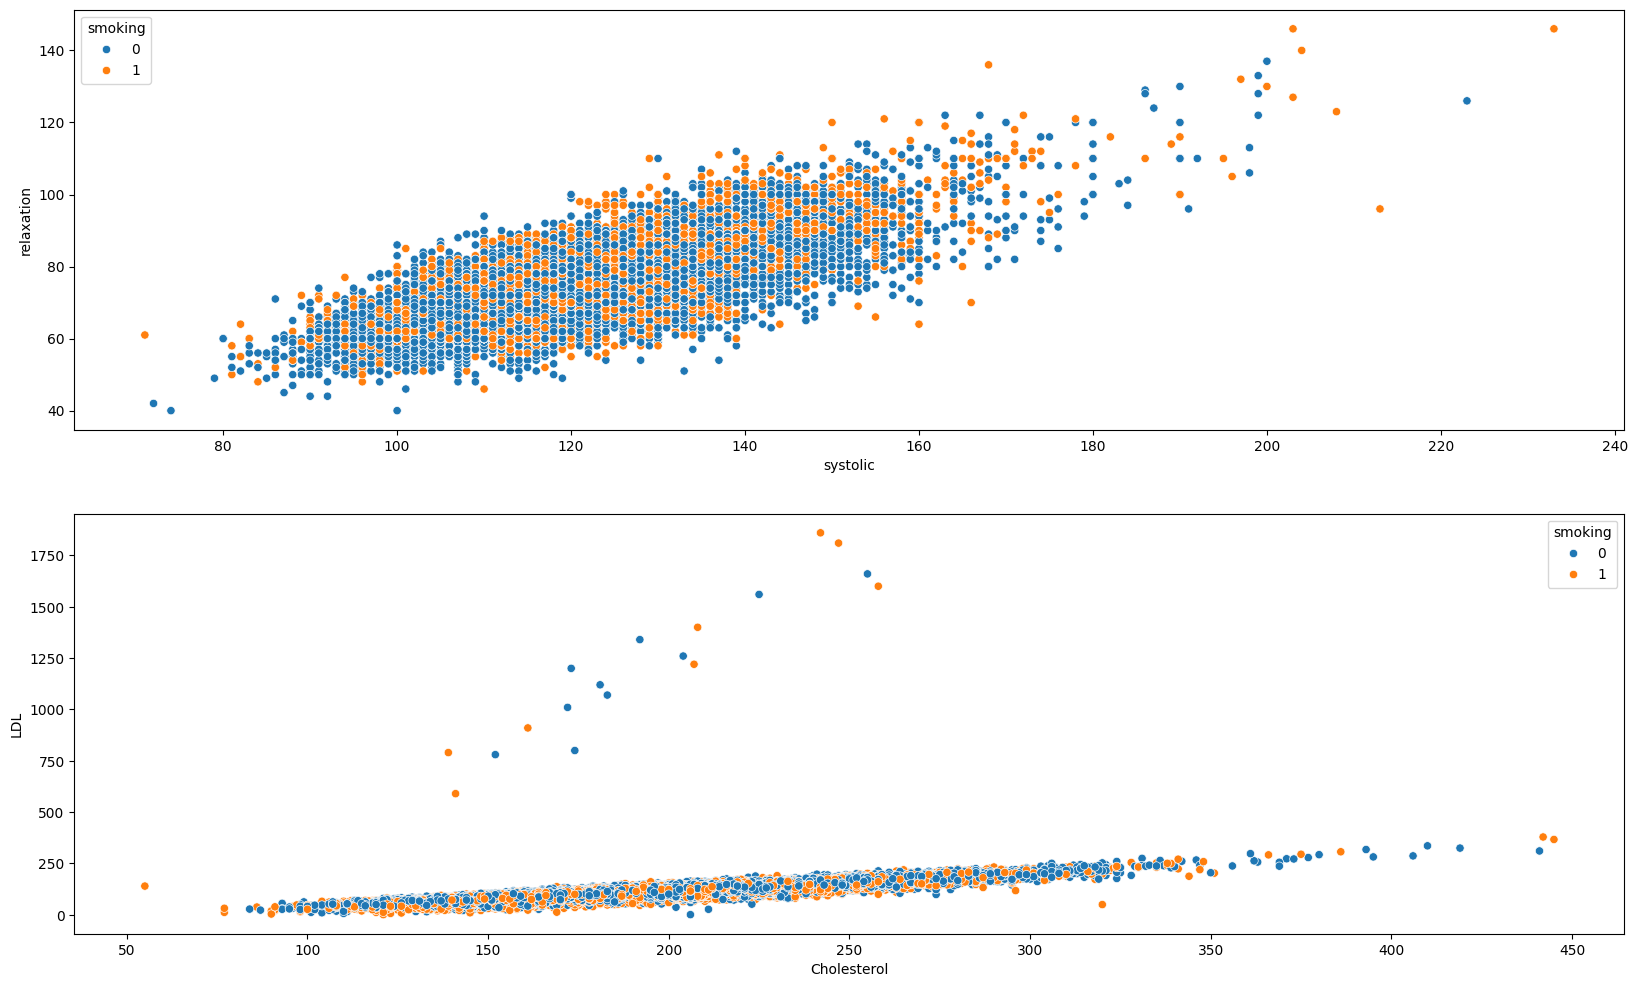

In [87]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

sns.scatterplot(ax=axes[0], data=train_df, x='systolic', y='relaxation', hue='smoking')
sns.scatterplot(ax=axes[1], data=train_df, x='Cholesterol', y='LDL', hue='smoking')

plt.show()

## Distribution of Target

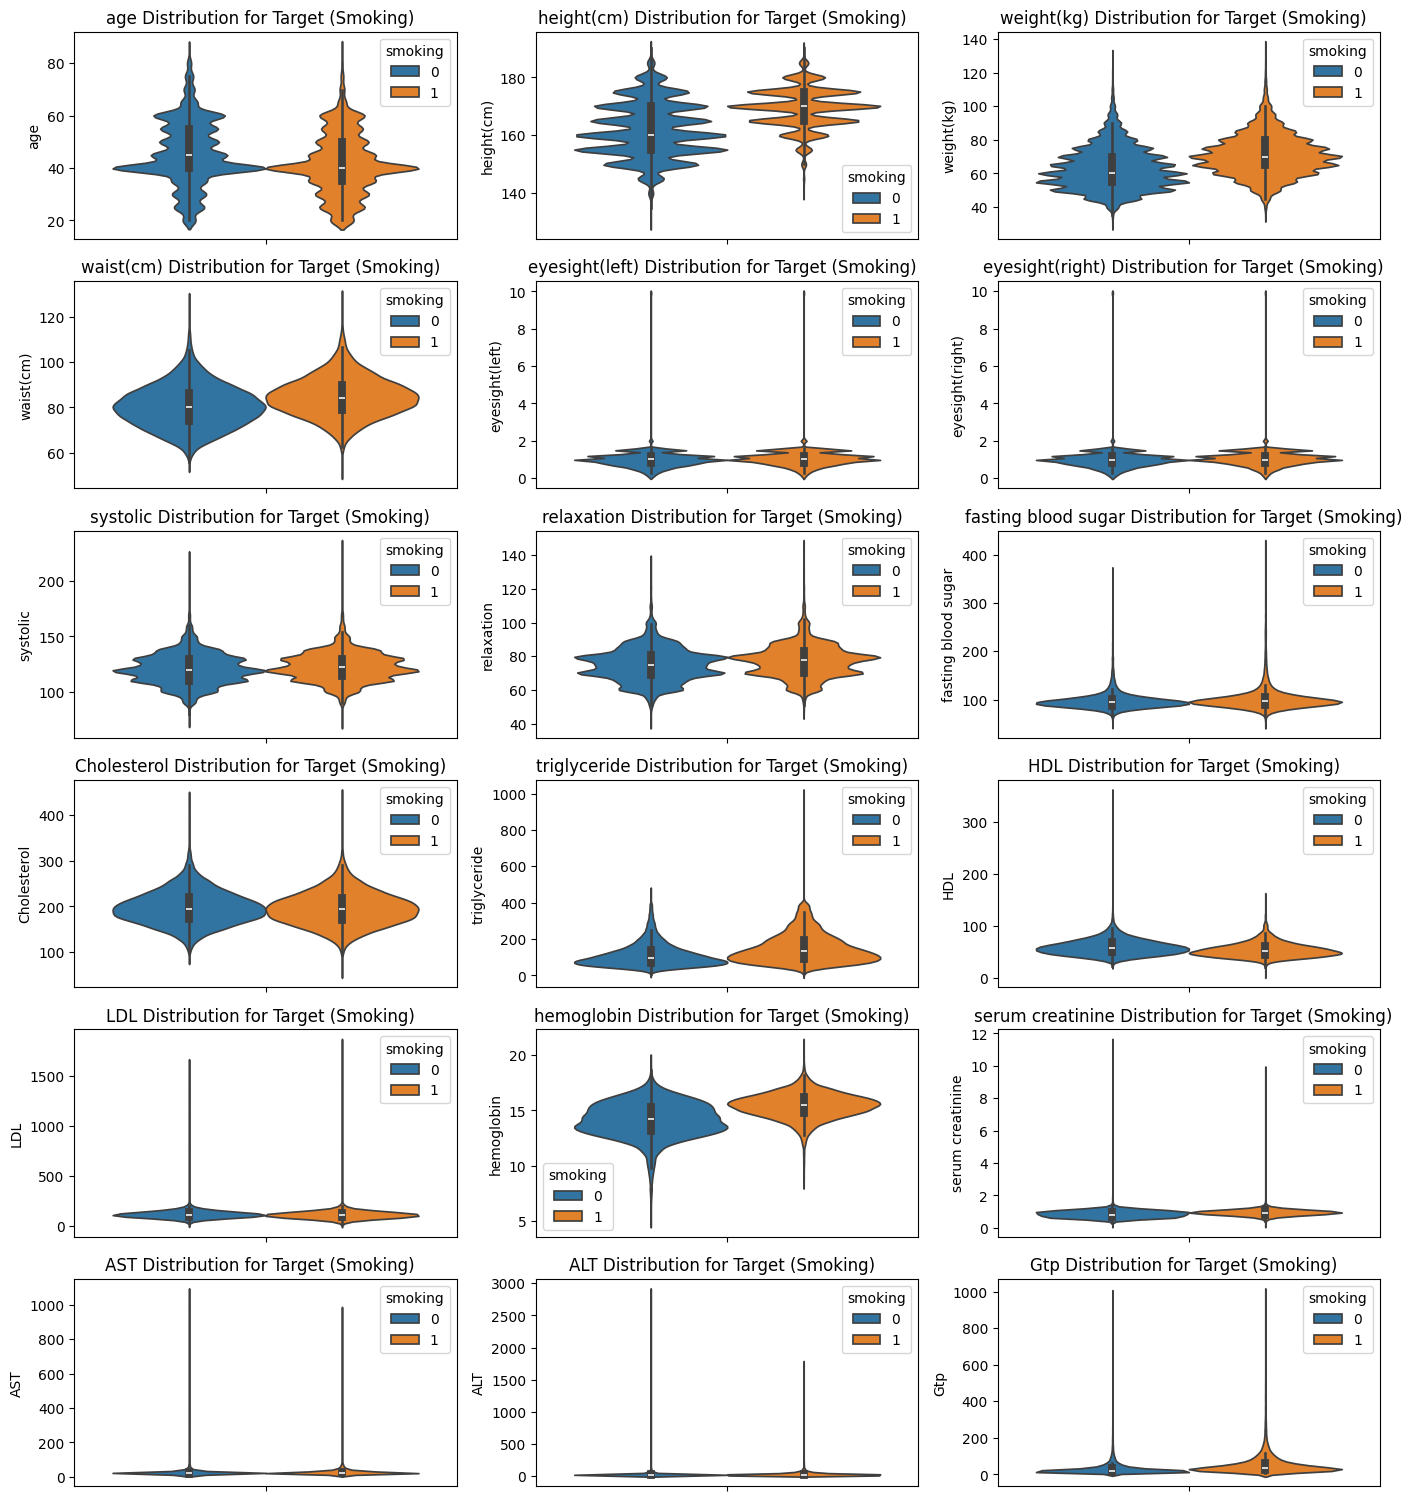

In [88]:
#Distribution of Target

num_rows = len(num_var)
num_cols = 3

total_plots = num_rows * num_cols
plt.figure(figsize=(14, num_rows * 2.5))

for idx, col in enumerate(num_var):
    plt.subplot(num_rows, num_cols, idx % total_plots + 1)
    sns.violinplot(hue='smoking', y=col, data=train_df)
    plt.title(f"{col} Distribution for Target (Smoking)  ")

plt.tight_layout()
plt.show()

 We can see some differences between the distributions of the variables for smokers compared to non-smokers. There are significant differences in weight, hemoglobin and height. Also of interest is that the age distribution of non-smokers has a longer tail towards older ages.

## Distribution of Numeric Variables in Train/Test set

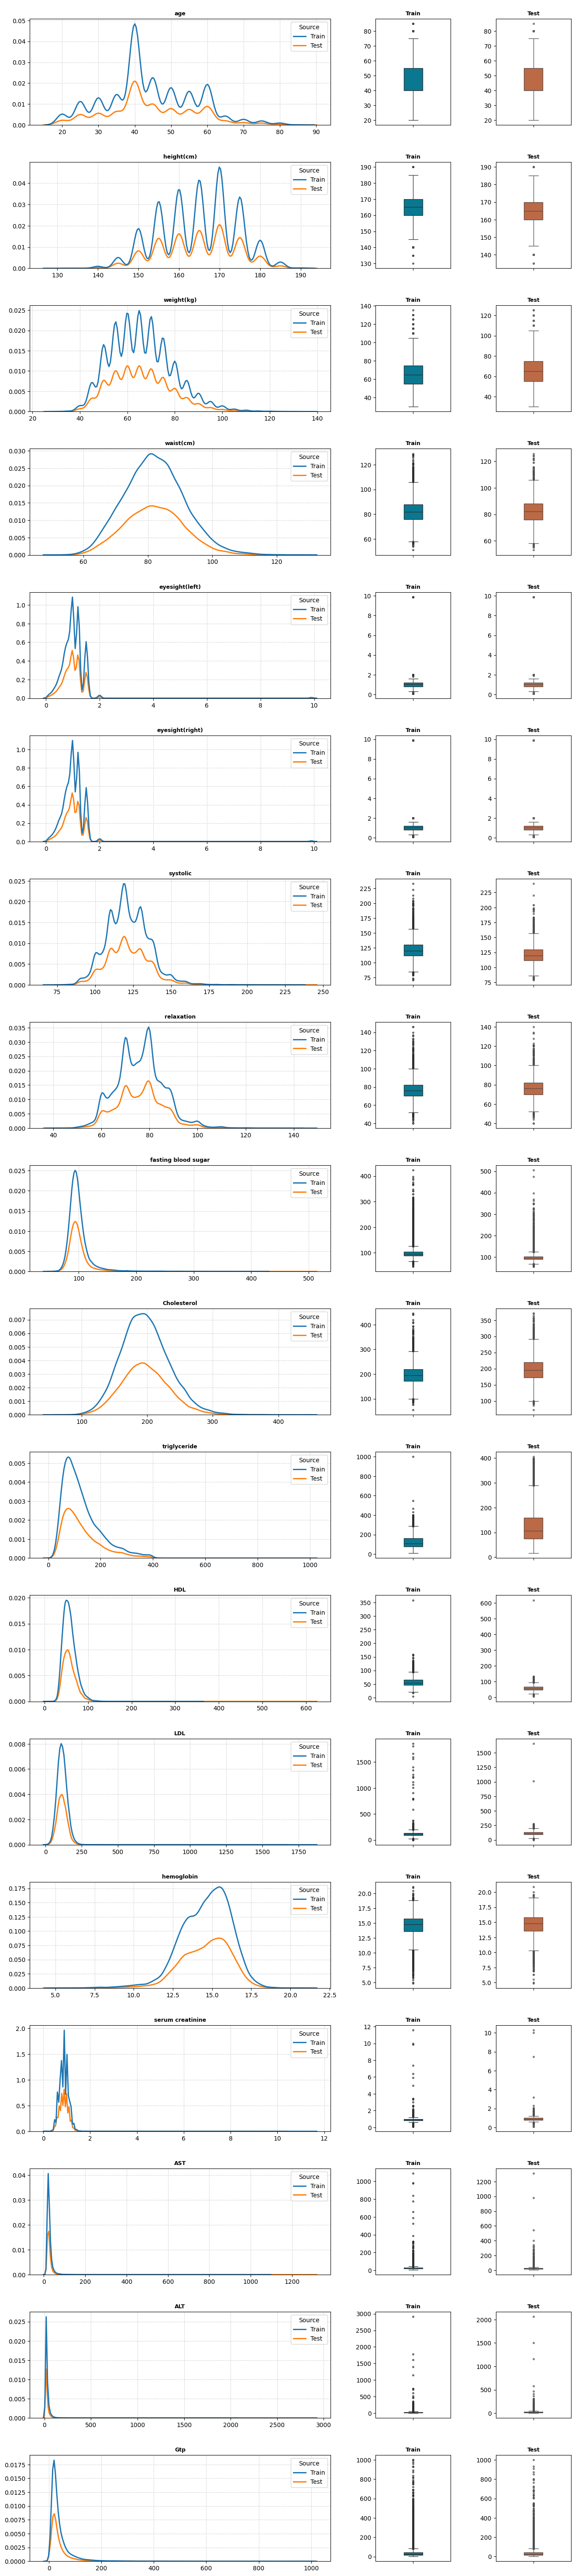

In [89]:

df1 = pd.concat([train_df[num_var].assign(Source = 'Train'),
                test_df[num_var].assign(Source = 'Test')],
               axis=0, ignore_index = True);

fig, axes = plt.subplots(len(num_var), 3 ,figsize = (16, len(num_var) * 4.2),
                         gridspec_kw = {'hspace': 0.35, 'wspace': 0.3, 'width_ratios': [0.80, 0.20, 0.20]});

for i,col in enumerate(num_var):
    ax = axes[i,0];
    sns.kdeplot(data = df1[[col, 'Source']], x = col, hue = 'Source', ax = ax, linewidth = 2.1)
    ax.set_title(f"\n{col}",fontsize = 9, fontweight= 'bold');
    ax.grid(visible=True, which = 'both', linestyle = '--', color='lightgrey', linewidth = 0.75);
    ax.set(xlabel = '', ylabel = '');
    ax = axes[i,1];
    sns.boxplot(data = df1.loc[df1.Source == 'Train', [col]], y = col, width = 0.25,saturation = 0.90, linewidth = 0.90, fliersize= 2.25, color = '#037d97',
                ax = ax);
    ax.set(xlabel = '', ylabel = '');
    ax.set_title(f"Train",fontsize = 9, fontweight= 'bold');

    ax = axes[i,2];
    sns.boxplot(data = df1.loc[df1.Source == 'Test', [col]], y = col, width = 0.25, fliersize= 2.25,
                saturation = 0.6, linewidth = 0.90, color = '#E4591E',
                ax = ax);
    ax.set(xlabel = '', ylabel = '');
    ax.set_title(f"Test",fontsize = 9, fontweight= 'bold');

plt.tight_layout();
plt.show();

### Some observation:

1. It seems that some variables have large skewness. For this case, we can perform log transformation on them.
2. In general, the data distribution of the training and test sets is similar.

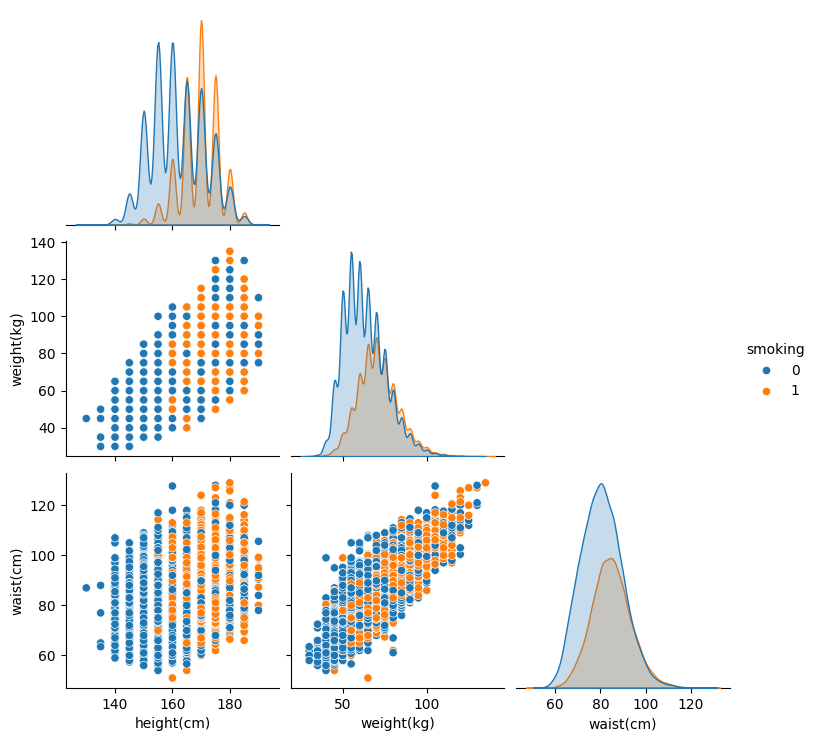

In [90]:

sns.pairplot(data = train_df[['height(cm)', 'weight(kg)', 'waist(cm)', 'smoking']], hue = 'smoking', corner = True);


### Some observation:

1. In some features(height,weight,waist), smoking or nonsmoking makes a significant difference in distribution.


# 4. Features Engineering
We can create some new features based on existing features.


In [91]:
print(train_df.shape)

(33467, 23)


In [92]:
print(train_df.shape)

def create_feature(data):

    # BMI = (weight/height**2)
    data['BMI'] = data['weight(kg)']/((data['height(cm)']/100)**2)

    # HW = height/waist
    data['HW_Ratio'] = data['height(cm)']/data['waist(cm)']

    #HA = height/age
    data['HA_Ratio'] = data['height(cm)']/data['age']

create_feature(train_df)

print(train_df.shape)

train_df.head()


(33467, 23)
(33467, 26)


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,HW_Ratio,HA_Ratio
0,35,170,85,97.0,0.9,0.9,1,1,118,78,97,239,153,70,142,19.8,1,1.0,61,115,125,1,1,29.411765,1.752577,4.857143
1,20,175,110,110.0,0.7,0.9,1,1,119,79,88,211,128,71,114,15.9,1,1.1,19,25,30,1,0,35.918367,1.590909,8.750000
2,45,155,65,86.0,0.9,0.9,1,1,110,80,80,193,120,57,112,13.7,3,0.6,1090,1400,276,0,0,27.055151,1.802326,3.444444
3,45,165,80,94.0,0.8,0.7,1,1,158,88,249,210,366,46,91,16.9,1,0.9,32,36,36,0,0,29.384757,1.755319,3.666667
4,20,165,60,81.0,1.5,0.1,1,1,109,64,100,179,200,47,92,14.9,1,1.2,26,28,15,0,0,22.038567,2.037037,8.250000


In [93]:
categorical_features = ['hearing(left)', 'hearing(right)', 'Urine protein', 'dental caries']
numerical_features = [feat for feat in train_df.columns if feat not in categorical_features and feat not in ['smoking']]


def one_hot_encode(df, categorical_features):
    """
    One-hot encode the specified categorical features in the given DataFrame.
    Parameters:
    - df (pandas DataFrame): The input DataFrame.
    - categorical_features (list of str): List of categorical feature names to be one-hot encoded.

    Returns:
    - pandas DataFrame: A DataFrame with the specified categorical features one-hot encoded.
    """
    return pd.get_dummies(df, columns=categorical_features)

#train_df = one_hot_encode(train_df, categorical_features)
#print(train_df.shape)
#train_df.head()

In [94]:
# Removing outliers using isolation forest
if_clf = IsolationForest(n_estimators = 2_000, contamination = 0.05, random_state = 42)

def remove_outliers(df):
    df = df.copy()
    if_pred = if_clf.fit_predict(df)
    df_outliers_removed = df[(if_pred == 1)]
    print(f"Removed {len(df) - len(df_outliers_removed)} outliers")
    print(df[(if_pred == -1)].head())
    return df_outliers_removed

train_df = remove_outliers(train_df)
print(train_df.shape)
train_df.head()

Removed 1674 outliers
    age  height(cm)  weight(kg)  ...        BMI  HW_Ratio  HA_Ratio
0    35         170          85  ...  29.411765  1.752577  4.857143
1    20         175         110  ...  35.918367  1.590909  8.750000
2    45         155          65  ...  27.055151  1.802326  3.444444
5    60         160          50  ...  19.531250  2.051282  2.666667
23   55         175          70  ...  22.857143  2.083333  3.181818

[5 rows x 26 columns]
(31793, 26)


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,HW_Ratio,HA_Ratio
3,45,165,80,94.0,0.8,0.7,1,1,158,88,249,210,366,46,91,16.9,1,0.9,32,36,36,0,0,29.384757,1.755319,3.666667
4,20,165,60,81.0,1.5,0.1,1,1,109,64,100,179,200,47,92,14.9,1,1.2,26,28,15,0,0,22.038567,2.037037,8.250000
6,40,175,90,95.0,0.9,1.0,1,1,130,88,90,207,331,39,102,16.5,1,1.0,19,22,19,0,0,29.387755,1.842105,4.375000
7,40,180,75,85.0,1.5,1.5,1,1,110,60,100,170,62,58,99,14.0,2,1.4,29,20,32,1,1,23.148148,2.117647,4.500000
8,40,170,60,74.0,1.2,1.5,1,1,89,57,83,178,69,60,104,12.9,2,0.7,17,17,14,0,0,20.761246,2.297297,4.250000


# 5. Splitting the Data

In [95]:
### Dependent & independent features

Y = train_df["smoking"]
X = train_df[train_df.columns.drop("smoking")]

### Train test/validation split

#splitting into train and test data
from sklearn.model_selection import train_test_split

X_train, X_valid, Y_train, Y_valid = train_test_split(X,Y,test_size=0.2,random_state=100)

X_train.shape, X_valid.shape


((25434, 25), (6359, 25))

# 6. Models

## LogisticRegression

In [96]:

#building and training the model
model = LogisticRegression()
model.fit(X_train,Y_train)

#Evaluating the model on the train and test data for R-squared score
train_score = model.score(X_train,Y_train)
test_score = model.score(X_valid, Y_valid)

print("Train score :", train_score)
print("Test score: ",test_score)

Train score : 0.7216324604859636
Test score:  0.7180374272684384


In [97]:
y_pred = model.predict(X_valid)

print("Test Accuracy:", accuracy_score(Y_valid, y_pred))
print(classification_report(Y_valid, y_pred))

# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(Y_valid, y_pred))

Test Accuracy: 0.7180374272684384
              precision    recall  f1-score   support

           0       0.76      0.82      0.79      4085
           1       0.63      0.53      0.57      2274

    accuracy                           0.72      6359
   macro avg       0.69      0.68      0.68      6359
weighted avg       0.71      0.72      0.71      6359

Confusion Matrix:
[[3370  715]
 [1078 1196]]


## SVM (Support vector Machine)

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC

In [99]:

# -----------------------------
#  Scale numerical features
# -----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_valid)

# -----------------------------
#  Define all SVM types
# -----------------------------

models = {
    "Linear SVM (SVC, linear kernel)": SVC(kernel='linear'),
    "RBF SVM": SVC(kernel='rbf', gamma='scale'),
}

# -----------------------------
# 5. Train & evaluate all models
# -----------------------------
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train_s, Y_train)

    y_pred = model.predict(X_test_s)

    print("Test Accuracy:", accuracy_score(Y_valid, y_pred))
    print(classification_report(Y_valid, y_pred))

    # confusion matrix
    print("Confusion Matrix:")
    print(confusion_matrix(Y_valid, y_pred))


===== Linear SVM (SVC, linear kernel) =====
Test Accuracy: 0.7320333385752477
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      4085
           1       0.64      0.58      0.61      2274

    accuracy                           0.73      6359
   macro avg       0.71      0.70      0.70      6359
weighted avg       0.73      0.73      0.73      6359

Confusion Matrix:
[[3340  745]
 [ 959 1315]]

===== RBF SVM =====
Test Accuracy: 0.7518477748073596
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      4085
           1       0.66      0.62      0.64      2274

    accuracy                           0.75      6359
   macro avg       0.73      0.72      0.73      6359
weighted avg       0.75      0.75      0.75      6359

Confusion Matrix:
[[3370  715]
 [ 863 1411]]


## Multi Layer Perceptron (MLP) -- Neural Networks

In [100]:
# -------------------------------
#  Scaling (VERY IMPORTANT for MLP)
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# -------------------------------
#  Model Definition
# -------------------------------

model = MLPClassifier(
    hidden_layer_sizes=(128, 256, 128),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=52,
    batch_size=128,
    random_state=42,
    verbose=True
)

In [101]:
# -------------------------------
#  Train
# -------------------------------
model.fit(X_train_scaled, Y_train)

# -------------------------------
#  Predict
# -------------------------------
y_pred = model.predict(X_valid_scaled)


Iteration 1, loss = 0.54305712
Iteration 2, loss = 0.49083905
Iteration 3, loss = 0.48220225
Iteration 4, loss = 0.47781753
Iteration 5, loss = 0.47491588
Iteration 6, loss = 0.47159117
Iteration 7, loss = 0.46918829
Iteration 8, loss = 0.46698312
Iteration 9, loss = 0.46474939
Iteration 10, loss = 0.46285622
Iteration 11, loss = 0.46091644
Iteration 12, loss = 0.46001775
Iteration 13, loss = 0.45775038
Iteration 14, loss = 0.45609298
Iteration 15, loss = 0.45422300
Iteration 16, loss = 0.45310718
Iteration 17, loss = 0.45174400
Iteration 18, loss = 0.44993161
Iteration 19, loss = 0.44859386
Iteration 20, loss = 0.44711477
Iteration 21, loss = 0.44550311
Iteration 22, loss = 0.44409948
Iteration 23, loss = 0.44220576
Iteration 24, loss = 0.44097102
Iteration 25, loss = 0.44005453
Iteration 26, loss = 0.43775954
Iteration 27, loss = 0.43653881
Iteration 28, loss = 0.43507905
Iteration 29, loss = 0.43361559
Iteration 30, loss = 0.43250984
Iteration 31, loss = 0.43031159
Iteration 32, los

In [102]:
# -------------------------------
# 6. Evaluate
# -------------------------------
acc = accuracy_score(Y_valid, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(Y_valid, y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_valid, y_pred))


Accuracy: 0.7402107249567542

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80      4085
           1       0.64      0.63      0.63      2274

    accuracy                           0.74      6359
   macro avg       0.72      0.72      0.72      6359
weighted avg       0.74      0.74      0.74      6359

Confusion Matrix:
 [[3277  808]
 [ 844 1430]]
